# 🧪 One-Tail vs Two-Tail Hypothesis Tests
## Complete Jupyter Notebook — 4 Real-World Datasets + Full Python Code

---

> 📌 **Tamil:** "Hypothesis Testing-இல் மிக முக்கியமான choice: One-tail test vs Two-tail test.  
> எப்போது எதை use பண்ணணும் என்று இந்த notebook-ல் 4 real datasets மூலம் learn பண்ணுவோம்."

---

### 4 Complete Projects in this Notebook

| Project | Dataset | Test Used | Business Question |
|---------|---------|-----------|-------------------|
| 1 | Drug trial (blood pressure) | One-tail t-test | Does drug *reduce* BP? |
| 2 | A/B button test (e-commerce) | Two-tail z-test | Does new button *change* conversion? |
| 3 | Salary audit | Two-tail t-test | Is there a gender pay gap? |
| 4 | Machine quality control | Two-tail + One-tail | Are fill weights off target? |

---

"ஒரு company அல்லது scientist என்ன பண்ணுவாங்கனா:
“இந்த change நல்லதா?”
“இந்த medicine வேலை செய்கிறதா?”
“இந்த machine சரியாக வேலை செய்கிறதா?”
இதை guess பண்ணாமல், data + statistics வைத்து check பண்ணுவாங்க. அதுதான்: 🎯 Hypothesis Testing"


ஒரு teacher சொல்றாங்க:
“இந்த புதிய study method marks increase பண்ணும்.” நாம் check பண்ணணும்.
இதில் இரண்டு possibilities:

| Type                        | Meaning                |
| --------------------------- | ---------------------- |
| Null Hypothesis (H₀)        | எந்த change-மும் இல்லை |
| Alternative Hypothesis (H₁) | change இருக்கு         |

"👉 One-Tail Test : இங்கே நாம் ஒரு direction மட்டும் check பண்ணுவோம்.
Example:
increase ஆகுதா?
decrease ஆகுதா?
ஒரே side மட்டும் பார்க்கும். “இந்த medicine BP-ஐ குறைக்கிறதா?” நாம் increase பற்றி கவலைப்படல.
குறைக்கிறதா மட்டும் பார்க்கிறோம்."
Only LEFT side checked or Only RIGHT side checked

"👉 Two-Tail Test: “difference இருக்கா?” மட்டும் பார்க்கிறோம்.

Direction important இல்லை.
increase ஆனாலும்
decrease ஆனாலும்
எதுவும் change இருந்தா கண்டுபிடிக்கணும்.

“New website button conversion rate-ஐ மாற்றுகிறதா?”
அது:
improve ஆகலாம்
worsen ஆகலாம்
இரண்டுமே important."


## ⚙️ Step 0 — Imports & Utilities

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── palette ─────────────────────────────────────────────────
PURPLE = '#534AB7'; TEAL = '#0F6E56'; AMBER = '#BA7517'
CORAL  = '#993C1D'; BLUE  = '#185FA5'; DGRAY = '#5F5E5A'
LGRAY  = '#F1EFE8'

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FFFFFF',
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--',
    'font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,
})

# இந்த code ஒரு Hypothesis Testing notebook setup: (Testing environment setup)
# “Statistical test செய்ய தேவையான tools + graph settings + helper function” எல்லாம் first prepare பண்ணுறோம்.
# இது ஒரு cricket match ஆரம்பிக்கும்முன்:
# bat ready
# ball ready
# scoreboard ready
# பண்ணுவது மாதிரி 😄

# ── helper: draw annotated normal curve ─────────────────────
from scipy.stats import norm as _norm
import numpy as _np

# Hypothesis test graph draw செய்யும்:  bell curve, rejection region, critical value, t-statistic, p-value எல்லாம் visualize பண்ணும்.
def plot_hypothesis(ax, t_stat, df_val, alpha, tail,
                    title='', test_type='t'):
    """Draw normal/t curve with rejection region, critical value, test statistic."""
    x = _np.linspace(-4, 4, 400) # -4 இருந்து +4 வரை 400 points create பண்ணும் Bell curve smooth-aa draw ஆக.
    if test_type == 't':
        y  = stats.t.pdf(x, df=df_val)
        cv = stats.t.ppf(1-alpha, df=df_val) if tail=='one' else stats.t.ppf(1-alpha/2, df=df_val)
        p  = stats.t.sf(abs(t_stat), df=df_val) * (1 if tail=='one' else 2)
    else:
        y  = stats.norm.pdf(x)
        cv = stats.norm.ppf(1-alpha) if tail=='one' else stats.norm.ppf(1-alpha/2)
        p  = stats.norm.sf(abs(t_stat)) * (1 if tail=='one' else 2)

    ax.plot(x, y, color=DGRAY, linewidth=2)

    # shade rejection region(s) - Danger zone color fill.
# One-Tail- Only one side shade.
# Two-Tail- Both sides shade.
    if tail == 'one':
        xf = x[x >= cv]
        ax.fill_between(xf, 0,
                        stats.t.pdf(xf, df=df_val) if test_type=='t' else stats.norm.pdf(xf),
                        color=CORAL, alpha=0.35, label=f'Rejection region (α={alpha})')
    else:
        for sign in [-1, 1]:
            xf = x[sign*x >= cv] if sign==1 else x[-x >= cv]
            ax.fill_between(xf, 0,
                            stats.t.pdf(xf, df=df_val) if test_type=='t' else stats.norm.pdf(xf),
                            color=CORAL, alpha=0.35,
                            label=f'Rejection region (α/2={alpha/2:.3f})' if sign==1 else '')

    # critical value line(s) - Vertical dashed line. - “இதுக்கு அப்புறம் reject zone
    cvs = [cv] if tail=='one' else [-cv, cv]
    for c in cvs:
        ax.axvline(c, color=CORAL, linewidth=1.5, linestyle='--', alpha=0.8)
        ax.text(c, max(y)*0.55, f'cv={c:.2f}', color=CORAL, fontsize=8,
                ha='left' if c > 0 else 'right')

    # test statistic line - Actual observed statistic.
#     | Thing          | Meaning       |
# | -------------- | ------------- |
# | Critical value | boundary      |
# | Test statistic | actual result |

    ax.axvline(t_stat, color=PURPLE, linewidth=2.5, linestyle='-')
    ax.text(t_stat, max(y)*0.75, f't={t_stat:.2f}', color=PURPLE,
            fontsize=9, fontweight='bold',
            ha='left' if t_stat < 0 else 'right')

    decision = 'REJECT H₀ ✓' if p < alpha else 'FAIL to reject H₀'
    col = CORAL if p < alpha else TEAL
    ax.set_title(f'{title}\np = {p:.4f} → {decision}', fontsize=10,
                 fontweight='bold', color=col)
    ax.set_xlabel('Test statistic'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    return p

print("✅ Imports and helper functions ready!")


✅ Imports and helper functions ready!


---
---
# 🔬 Project 1 — Drug Trial: Blood Pressure
## One-Tailed Paired t-test

---

### Business Problem
A pharmaceutical company has developed a new drug to reduce **systolic blood pressure**.  
They run a clinical trial on 80 patients — measuring BP before and after 8 weeks of treatment.

> 📌 **Tamil:** "Drug BP-ஐ குறைக்கிறதா? 'குறைக்கிறது' என்று தெரியும் — direction தெரியும் → One-tail test."

"Question:“BP குறையுதா?” நாம் check பண்ணுறது: decrease மட்டும் அதனால்: ✅ One-Tailed Test"

### Why One-Tail Here?
- H₀: Drug has **no effect** (mean difference = 0)
- H₁: Drug **reduces** BP (mean difference > 0, i.e. before > after)
- We only care if BP goes **down** — if it goes up, the drug fails regardless
- Direction is known → **one-tailed**

### Test: Paired t-test (same patients measured twice)


In [2]:
# Doctors 80 patients-க்கு:
# treatment முன் BP measure பண்ணுறாங்க
# 8 weeks drug கொடுக்குறாங்க
# treatment பிறகு மீண்டும் BP measure பண்ணுறாங்க
# அதுக்கப்புறம் compare பண்ணுறாங்க.

# Why Paired t-test? Same patients: before measurement after measurement இரண்டுமே same person. அதனால் data paired.

np.random.seed(42) # Random numbers generate பண்ணும் போது: ஒவ்வொரு run-லும் same output வர.
n_patients = 80

# Before treatment — patients with hypertension
bp_before = np.random.normal(loc=148, scale=14, size=n_patients) # loc = 148 mmHg இதுதான்: average BP

# After treatment — drug reduces by ~9 mmHg on average => சிகிச்சைக்குப் பிறகு — மருந்தின் அளவு சராசரியாக ~9 mmHg குறைகிறது.
bp_after  = bp_before - np.random.normal(loc=9, scale=8, size=n_patients) # Average reduction: 9 mmHg

df_drug = pd.DataFrame({
    'patient_id': [f'P{i:03d}' for i in range(1, n_patients+1)],
    'bp_before':  bp_before.round(1),
    'bp_after':   bp_after.round(1),
    'reduction':  (bp_before - bp_after).round(1),
    'age':        np.random.randint(35, 72, n_patients),
    'sex':        np.random.choice(['M','F'], n_patients)
})

df_drug.to_csv('drug_trial_bp.csv', index=False)
print("✅ Dataset: drug_trial_bp.csv")
print(f"   {len(df_drug)} patients | {df_drug.shape[1]} columns")
df_drug.head(8)


PermissionError: [Errno 13] Permission denied: 'drug_trial_bp.csv'

In [3]:
# ── Descriptive Statistics ───────────────────────────────────
reductions = df_drug['reduction']

# Extreme patients இருந்தாலும் median stable.
# Patient	Reduction
# Normal	8
# Normal	9
# Extreme	40
# Mean distort ஆகலாம். Median balanced.
print("── Blood Pressure Reduction (Before − After) ──")
print(f"  Mean reduction   : {reductions.mean():.2f} mmHg") #Average-ஆ patients BP 8.91 points குறைந்திருக்கு
print(f"  Median reduction : {reductions.median():.2f} mmHg") # All reductions sort பண்ணுவோம். Middle value, Half patients: 9.5-க்கு கீழ் reduction, 9.5-க்கு மேல் reduction
print(f"  Std Dev          : {reductions.std():.2f} mmHg") # Patients improvement எவ்வளவு vary ஆகுது?
print(f"  Patients improved: {(reductions > 0).sum()} / {len(reductions)}") # 80 patients-ல்: 69 patients improve ஆனாங்க
# Possibly: no improvement, side effects, BP increase
print()
print(f"  Before — Mean: {df_drug['bp_before'].mean():.2f}, Std: {df_drug['bp_before'].std():.2f}")
print(f"  After  — Mean: {df_drug['bp_after'].mean():.2f},  Std: {df_drug['bp_after'].std():.2f}")


# 👨‍⚕️ Doctors 80 patients data analyze பண்ணாங்க.
# அவர்கள் கண்டுபிடித்தது:
# Average BP almost 9 mmHg குறைந்தது
# 69 patients improve ஆனாங்க
# After-treatment BP clearly lower
# இதனால்:
# “Drug வேலை செய்கிற மாதிரி தெரிகிறது…”
# ஆனா scientists இன்னும் careful:
# “Statistics மூலம் proof வேண்டும்.”
# அதற்காக next step:
# 🧪 One-Tailed Paired t-test 🚀


── Blood Pressure Reduction (Before − After) ──
  Mean reduction   : 8.91 mmHg
  Median reduction : 9.50 mmHg
  Std Dev          : 7.34 mmHg
  Patients improved: 69 / 80

  Before — Mean: 146.27, Std: 13.40
  After  — Mean: 137.35,  Std: 15.35


### Setting Up the Hypothesis Test

| | Formula |
|--|--------|
| **H₀** | μ_before − μ_after = 0 (no effect) |
| **H₁** | μ_before − μ_after > 0 (drug reduces BP) |
| **α** | 0.05 |
| **Test** | Paired t-test (one-tailed) |
| **Why paired?** | Same patients measured before AND after |

"📌 Why “> 0” ? Before - After
Positive வந்தா: reduction நடந்தது"

α = 0.05 - "5% error risk accept பண்ணுறோம்.
Scientists சொல்றாங்க: “5% chance வரை random error okay.”"

> 📌 **Tamil:** "Same patient-ஐ இரண்டு முறை measure பண்றோம் → paired t-test. One-tail → only interested in reduction, not increase."


In [4]:
# ── ONE-TAILED Paired t-test ─────────────────────────────────
from ast import Pass
from multiprocessing.sharedctypes import Value


t_stat, p_two = stats.ttest_rel(df_drug['bp_before'], df_drug['bp_after'])
p_one = p_two / 2   # one-tailed p = two-tailed p / 2 (when t > 0)

# 🎯 What is t-statistic?
# “Difference எவ்வளவு strong?”
# 🎯 Larger t-statistic
# means: stronger evidence
# | t-statistic | Meaning          |
# | ----------- | ---------------- |
# | 0.5         | weak             |
# | 2.1         | moderate         |
# | 8.0         | extremely strong |


df_val = n_patients - 1
alpha  = 0.05
cv_one = stats.t.ppf(1 - alpha, df=df_val)  # critical value - “இதுக்கு அப்புறம் reject zone”


print("═" * 55)
print("  ONE-TAILED PAIRED t-TEST RESULTS")
print("═" * 55)
print(f"  t-statistic       : {t_stat:.4f}")
print(f"  Degrees of freedom: {df_val}")
print(f"  Critical value    : {cv_one:.4f}  (α=0.05, one-tail)")
print(f"  p-value (one-tail): {p_one:.6f}")
print()
print(f"  Decision rule: reject H₀ if t > {cv_one:.3f} or p < {alpha}")
print(f"  t = {t_stat:.3f} > {cv_one:.3f}?  {t_stat > cv_one}")
print(f"  p = {p_one:.4f} < {alpha}?        {p_one < alpha}")
print()
if p_one < alpha:
    print(f"  ✅ REJECT H₀ — The drug significantly reduces BP")
    print(f"     Average reduction: {reductions.mean():.1f} mmHg (p = {p_one:.4f})")
    print(f"     This reduction is statistically significant at α = {alpha}")
else:
    print(f"  ❌ FAIL to reject H₀ — No significant reduction found")

print()
# 95% confidence interval for mean reduction
ci = stats.t.interval(0.95, df=df_val,
                       loc=reductions.mean(),
                       scale=stats.sem(reductions))
print(f"  95% CI for mean reduction: ({ci[0]:.2f}, {ci[1]:.2f}) mmHg") # 95% confidence interval: true mean reduction எங்கே இருக்கலாம் என்று range
print(f"  → We are 95% confident the true mean reduction is in this range")



# 🧠 Think Like Exam Pass Mark
# # Exam	        Pass Mark
# # Statistics exam	35
# If you score: 90 > 35
# Clearly pass.
# Thing	                Value
# Required boundary	    1.664
# Actual t-statistic	10.864
# 😮 Scientists பார்த்தவுடன்… “Wow… இது boundary-ஐ ரொம்ப தாண்டி போயிருக்கு!”
# 🎯 Meaning Drug effect: statistically VERY strong

# 📊 p-value = 0.000000
# Room silent ஆகுது 😶
# ஒரு researcher சொல்றார்: “இந்த result random chance-ஆ வந்த probability almost zero.”

# Suppose drug actually useless.
# அப்படியிருந்தும் இப்படியொரு huge improvement வர chance: almost impossible

# ✅ Condition 1: 10.864 > 1.664 : TRUE ✅
# ✅ Condition 2: 0.0000 < 0.05 : TRUE ✅

# 🎯 Both conditions satisfied
# So final decision: ✅ REJECT H₀
# 🧠 Meaning of Reject H₀
# Null hypothesis சொன்னது:“Drug has no effect.”
# Scientists now say: ❌ “That is NOT true.”


═══════════════════════════════════════════════════════
  ONE-TAILED PAIRED t-TEST RESULTS
═══════════════════════════════════════════════════════
  t-statistic       : 10.8636
  Degrees of freedom: 79
  Critical value    : 1.6644  (α=0.05, one-tail)
  p-value (one-tail): 0.000000

  Decision rule: reject H₀ if t > 1.664 or p < 0.05
  t = 10.864 > 1.664?  True
  p = 0.0000 < 0.05?        True

  ✅ REJECT H₀ — The drug significantly reduces BP
     Average reduction: 8.9 mmHg (p = 0.0000)
     This reduction is statistically significant at α = 0.05

  95% CI for mean reduction: (7.28, 10.54) mmHg
  → We are 95% confident the true mean reduction is in this range


In [5]:
# | Test Type | Purpose                      |
# | --------- | ---------------------------- |
# | One-Tail  | Reduction மட்டும் பார்க்கும் |
# | Two-Tail  | Any change பார்க்கும்        |

# 📌 Real Medical Question:
# Company question:“Drug BP-ஐ குறைக்கிறதா?”
# NOT: “Drug BP-ஐ எந்த direction-லாவது change பண்ணுதா?”

# ── WHY NOT TWO-TAIL? Comparison ────────────────────────────
t_stat2, p_two2 = stats.ttest_rel(df_drug['bp_before'], df_drug['bp_after'])
cv_two = stats.t.ppf(1 - alpha/2, df=df_val)

print("── Comparison: One-tail vs Two-tail ──")
print(f"  {'Metric':<30} {'One-tail':>12} {'Two-tail':>12}")
print("  " + "─"*56)
print(f"  {'Alpha (α)':<30} {alpha:>12.2f} {alpha:>12.2f}")
print(f"  {'Critical value':<30} {cv_one:>12.4f} {cv_two:>12.4f}")
print(f"  {'p-value':<30} {p_one:>12.6f} {p_two2:>12.6f}")
print(f"  {'Reject H₀?':<30} {'YES' if p_one<alpha else 'NO':>12} {'YES' if p_two2<alpha else 'NO':>12}")
print()
print("  ► One-tail has MORE power (lower critical value)")
print("    Use it ONLY when direction is certain from prior knowledge")

# One-Tail : Police already know thief went RIGHT 👉 So all officers search right side only. Easy to catch.
# Two-Tail Police search: left, right. Split resources. Harder.

# 📉 One-Tail Visual
# -------------|======
# 🧠 But Two-Tail
# 5%-ஐ split பண்ணும்.
# ==|-------------|==
# 2.5% left
# 2.5% right

# | Concept                 | Meaning                    |
# | ----------------------- | -------------------------- |
# | One-tail                | One direction only         |
# | Two-tail                | Both directions            |
# | One-tail critical value | Smaller                    |
# | Two-tail critical value | Larger                     |
# | One-tail power          | Higher                     |
# | Why higher power?       | Entire α in one side       |
# | Use one-tail when       | Direction already known    |
# | Wrong usage             | Choosing after seeing data |

# | Alternative Hypothesis | Test     |
# | ---------------------- | -------- |
# | >                      | One-tail |
# | <                      | One-tail |
# | ≠                      | Two-tail |



── Comparison: One-tail vs Two-tail ──
  Metric                             One-tail     Two-tail
  ────────────────────────────────────────────────────────
  Alpha (α)                              0.05         0.05
  Critical value                       1.6644       1.9905
  p-value                            0.000000     0.000000
  Reject H₀?                              YES          YES

  ► One-tail has MORE power (lower critical value)
    Use it ONLY when direction is certain from prior knowledge


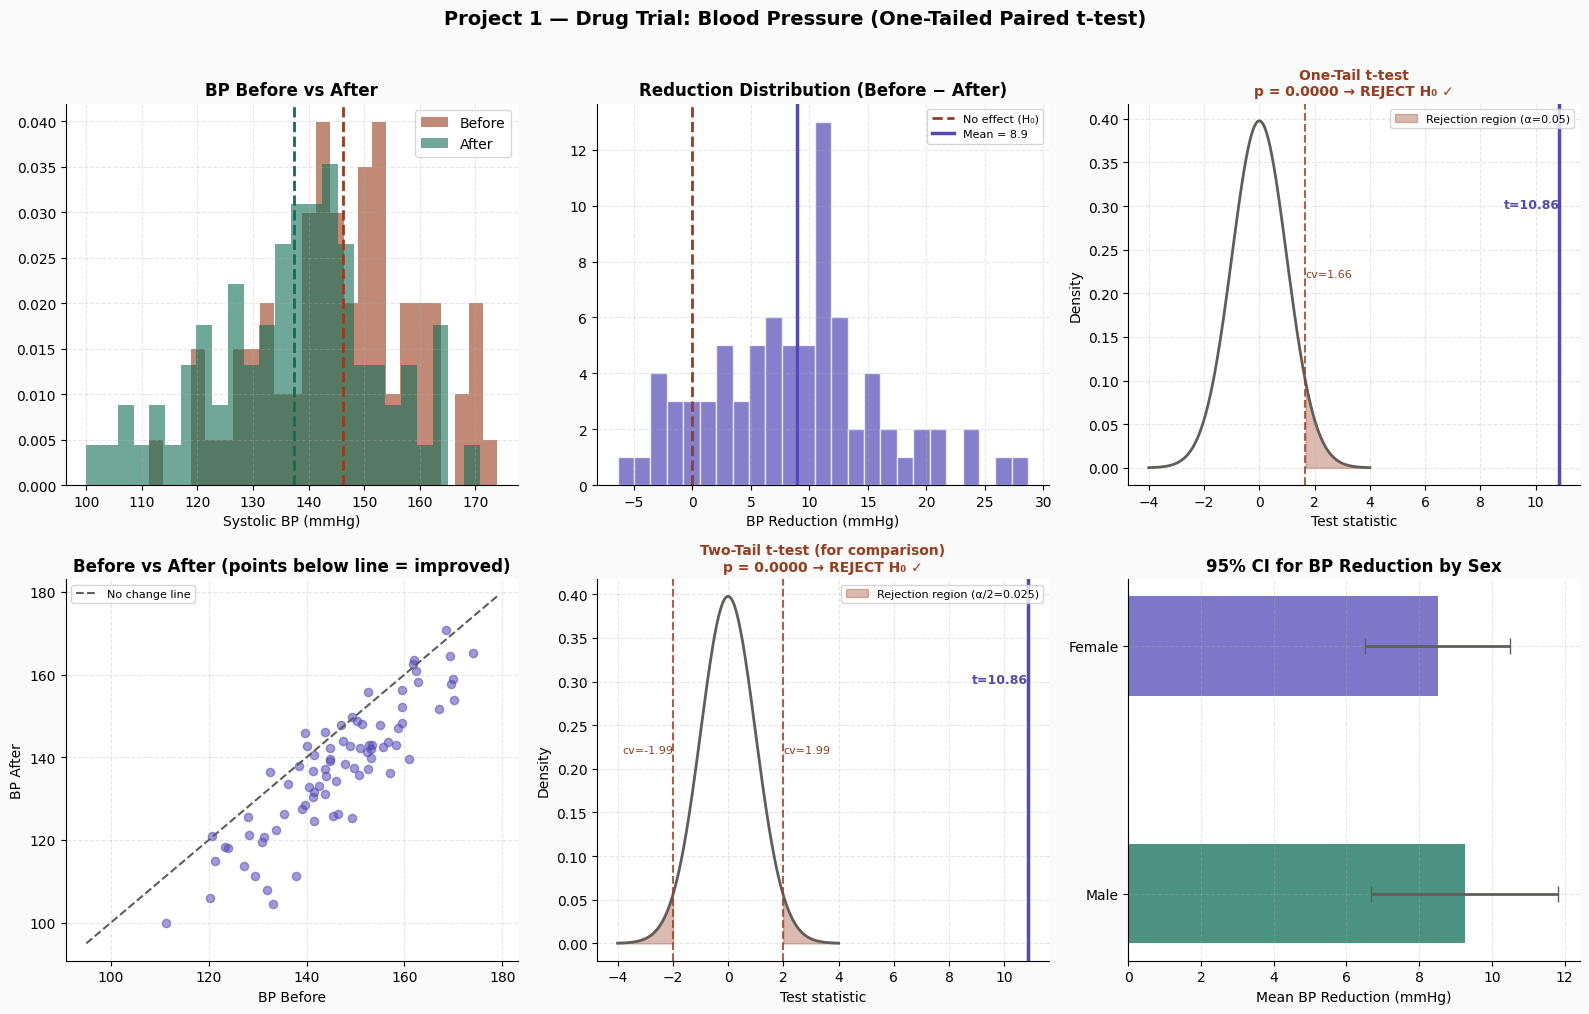

✅ Chart saved: p1_drug_trial.png


In [6]:
# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Project 1 — Drug Trial: Blood Pressure (One-Tailed Paired t-test)',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Before vs After distribution
axes[0,0].hist(df_drug['bp_before'], bins=25, color=CORAL,  alpha=0.6, label='Before', density=True)
axes[0,0].hist(df_drug['bp_after'],  bins=25, color=TEAL,   alpha=0.6, label='After',  density=True)
axes[0,0].axvline(df_drug['bp_before'].mean(), color=CORAL, linewidth=2, linestyle='--')
axes[0,0].axvline(df_drug['bp_after'].mean(),  color=TEAL,  linewidth=2, linestyle='--')
axes[0,0].set_title('BP Before vs After', fontweight='bold')
axes[0,0].set_xlabel('Systolic BP (mmHg)'); axes[0,0].legend()

# 😮 Doctors Reaction: “Wow… whole BP distribution left-க்கு shift ஆகியிருக்கு!”
# 🎯 Medical Meaning : Patients overall improved.

# 2. Reduction distribution
axes[0,1].hist(reductions, bins=25, color=PURPLE, alpha=0.7, edgecolor='white')
axes[0,1].axvline(0, color=CORAL, linewidth=2, linestyle='--', label='No effect (H₀)')
axes[0,1].axvline(reductions.mean(), color=PURPLE, linewidth=2.5,
                   label=f'Mean = {reductions.mean():.1f}')
axes[0,1].set_title('Reduction Distribution (Before − After)', fontweight='bold')
axes[0,1].set_xlabel('BP Reduction (mmHg)'); axes[0,1].legend(fontsize=8)

# Right Side of 0: Positive reduction: BP decreased ✅
# Left Side of 0: Negative reduction ,BP increased ❌
# Most bars: RIGHT SIDE: Majority patients improved.

# 📍 Blue Mean Line: Average reduction: 8.9 mmHg
# Scientists சொல்றாங்க: “Typical patient almost 9 mmHg improvement.”

# 3. One-tail hypothesis curve
plot_hypothesis(axes[0,2], t_stat, df_val, alpha=0.05, tail='one',
                title='One-Tail t-test', test_type='t')

# Two Side Rejection Regions
# --------|█████████|--------
#         cv1        cv2
# 👉 Both sides shaded (right and left) இந்த graph சொல்லுது: “If result extreme right or left side-க்கு போச்சா → reject H₀”


# 🟥 Red Shaded Region: Rejection region

# 4. Scatter: before vs after
axes[1,0].scatter(df_drug['bp_before'], df_drug['bp_after'],
                   color=PURPLE, alpha=0.55, s=35)
lims = [min(df_drug['bp_before'].min(), df_drug['bp_after'].min())-5,
        max(df_drug['bp_before'].max(), df_drug['bp_after'].max())+5]
axes[1,0].plot(lims, lims, color=DGRAY, linestyle='--', linewidth=1.5, label='No change line')
axes[1,0].set_xlabel('BP Before'); axes[1,0].set_ylabel('BP After')
axes[1,0].set_title('Before vs After (points below line = improved)', fontweight='bold')
axes[1,0].legend(fontsize=8)

# Each dot = one patient.
# 📉 Dashed Diagonal Line : No change line

# Point BELOW line: Improvement ✅
# Point ABOVE line: Worse ❌

# 5. Two-tail for comparison
plot_hypothesis(axes[1,1], t_stat, df_val, alpha=0.05, tail='two',
                title='Two-Tail t-test (for comparison)', test_type='t')
# BOTH directions check பண்ணுது
# “Drug BP-ஐ increase ஆகுதா? decrease ஆகுதா? எதுவானாலும் பார்க்கணும்.”
# ███-----|-----███     👉 Left side + Right side shaded - ±1.99 👉 Two boundaries - Still: 👉 t = 10.86 (far right)
#    -cv       +cv



# 6. CI plot
means_sex = df_drug.groupby('sex')['reduction'].agg(['mean','sem','count'])
for i, (sex, row) in enumerate(means_sex.iterrows()):
    ci95 = stats.t.interval(0.95, df=row['count']-1, loc=row['mean'], scale=row['sem'])
    axes[1,2].barh(i, row['mean'], color=PURPLE if sex=='M' else TEAL,
                    alpha=0.75, height=0.4)
    axes[1,2].errorbar(row['mean'], i, xerr=[[row['mean']-ci95[0]],[ci95[1]-row['mean']]],
                        fmt='none', color=DGRAY, capsize=6, linewidth=2)
axes[1,2].set_yticks([0,1]); axes[1,2].set_yticklabels(['Male','Female'])
axes[1,2].axvline(0, color=CORAL, linestyle='--', linewidth=1.5)
axes[1,2].set_title('95% CI for BP Reduction by Sex', fontweight='bold')
axes[1,2].set_xlabel('Mean BP Reduction (mmHg)')

# Both intervals: completely positive
# Drug effective in BOTH genders.
# “Excellent… effect consistent across groups.”

plt.tight_layout()
plt.savefig('p1_drug_trial.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Chart saved: p1_drug_trial.png")


# 🟣 One-Tail Graph
# “Drug BP குறைக்கிறதா?”
# 👉 Only RIGHT side check

# 🔵 Two-Tail Graph
# “Any change இருக்கா?”
# 👉 LEFT + RIGHT check


---
---
# 🛒 Project 2 — A/B Test: E-commerce Button
## Two-Tailed Two-Proportion Z-test

---

### Business Problem
An e-commerce company tests whether changing the "Buy Now" button from **orange** (Control A) to **green** (Treatment B) changes the conversion rate.

> 📌 **Tamil:** "Button color-ஐ change பண்ணினால் conversion rate மாறுமா? Direction தெரியாது — up ஆகலாம், down ஆகலாம் → Two-tail test."

### Why Two-Tail Here?
- H₀: Conversion rate is the **same** for both buttons (p_A = p_B)
- H₁: Conversion rate is **different** (p_A ≠ p_B) — could go up OR down
- We don't know if green is better or worse before seeing data
- Direction unknown → **two-tailed**  - Direction தெரியாததால் (increase or decrease), இரண்டு பக்கத்தையும் check பண்ணும் test தான் Two-Tailed Z-test.

### Test: Two-proportion Z-test

ஒரு e-commerce shop இருந்தது.
அந்த shop-ல ஒரு பெரிய கேள்வி வந்தது:
“Buy Now button orange இருக்கா நல்லா convert ஆகுது… இல்ல green ஆக மாற்றினா இன்னும் sales அதிகமா வருமா?”
அவர்கள் இரண்டு குழுக்களை உருவாக்கினார்கள்:

🟠 Group A (Control) → Orange button
🟢 Group B (Treatment) → Green button

இரண்டு குழுக்களுக்கும் website காட்டினார்கள்.
ஆனால் யாருக்கும் தெரியாது:

Green நல்லதா?
இல்ல Orange தான் better ஆ?
இல்ல இரண்டும் same ஆ?

👉 அதனால் direction தெரியாது
👉 Increase ஆகலாம் / decrease ஆகலாம்


In [ ]:
np.random.seed(99)

# Control A: orange button — 5.2% conversion(மாற்றம்)
n_A, true_rate_A = 5000, 0.052
# Treatment B: green button — 5.8% conversion
n_B, true_rate_B = 5000, 0.058

# 1 = converted (buy), 0 = not converted
conversions_A = np.random.binomial(1, true_rate_A, n_A)
conversions_B = np.random.binomial(1, true_rate_B, n_B)

df_ab = pd.DataFrame({
    'user_id':    [f'U{i:05d}' for i in range(1, n_A+n_B+1)],
    'group':      ['Control']*n_A + ['Treatment']*n_B,
    'button':     ['Orange']*n_A + ['Green']*n_B,# group (Control → Orange , Treatment → Green)
    'converted':  np.concatenate([conversions_A, conversions_B]),
    'session_time': np.concatenate([
        np.random.exponential(180, n_A),
        np.random.exponential(195, n_B)
    ]).round(0)
})

df_ab.to_csv('ab_test_button.csv', index=False)
print("✅ Dataset: ab_test_button.csv")
print(f"   {len(df_ab):,} users | {df_ab.shape[1]} columns")
df_ab.head(8)


✅ Dataset: ab_test_button.csv
   10,000 users | 5 columns


,user_id,group,button,converted,session_time
0,U00001,Control,Orange,0,103.0
1,U00002,Control,Orange,0,911.0
2,U00003,Control,Orange,0,81.0
3,U00004,Control,Orange,0,13.0
4,U00005,Control,Orange,0,436.0
5,U00006,Control,Orange,0,23.0
6,U00007,Control,Orange,0,27.0
7,U00008,Control,Orange,0,385.0


In [ ]:
# ── Summary stats ────────────────────────────────────────────
grp = df_ab.groupby('group').agg(
    users        = ('user_id','count'),
    conversions  = ('converted','sum'),
    conv_rate    = ('converted','mean'),
).round(4)

print("── A/B Test Summary ──")
print(grp.to_string())

conv_A = df_ab[df_ab['group']=='Control']['converted'].sum()
conv_B = df_ab[df_ab['group']=='Treatment']['converted'].sum()
rate_A = conv_A / n_A
rate_B = conv_B / n_B
lift   = (rate_B - rate_A) / rate_A * 100

print(f"\n  Conversion lift: {lift:+.2f}%")
print(f"  Absolute lift  : {rate_B-rate_A:+.4f} ({(rate_B-rate_A)*100:+.2f} pp)") # (0.060 - 0.053) / 0.053 × 100 = 13.21% - 👉 Green button, Orange button-ஐ விட:
# ✅ 13.21% better performance காட்டுது -> pp = percentage points

# 🟠 Orange Button (Control)
# 265 conversions / 5000 users = 0.053 = 5.3% - 5000 பேரில் 265 பேர் buy பண்ணினாங்க
# 🟢 Green Button (Treatment)
# 300 conversions / 5000 users = 0.060 = 6.0% - 5000 பேரில் 300 பேர் buy பண்ணினாங்க
# 300 - 265 = 35  - Green button காரணமாக: 35 EXTRA customers buy பண்ணிருக்காங்க

# 0.007 × 100 = 0.7 - every 100 users-க்கு 0.7 extra conversion
# அதாவது:
# 100 users → almost 1 extra customer
# 1000 users → 7 extra customers
# 5000 users → 35 extra customers ✅

# 🛍 Real Business Interpretation
# Imagine ஒரு website-க்கு:தினமும் 5,000 visitors வருது
# Orange button use பண்ணா:265 sales
# Green button use பண்ணா:300 sales👉 தினமும் +35 extra orders
# If one order = ₹1000 profit:35 × ₹1000 = ₹35,000 extra/day

# 📈 Step 2: Business Question,Company கேட்குது:
# “இந்த difference meaningful ஆ? இல்ல random chance ஆ?”



── A/B Test Summary ──
           users  conversions  conv_rate
group                                   
Control     5000          265      0.053
Treatment   5000          300      0.060

  Conversion lift: +13.21%
  Absolute lift  : +0.0070 (+0.70 pp)


### The Two-Proportion Z-test

**Pooled proportion formula:**
```
p_pool = (conv_A + conv_B) / (n_A + n_B)
SE     = sqrt(p_pool × (1 − p_pool) × (1/n_A + 1/n_B))
Z      = (rate_B − rate_A) / SE
```

> 📌 **Tamil:** "இரண்டு groups-இன் proportions equal-ஆ இல்லையா என்று test பண்றோம்.  
> p_pool = overall conversion rate under H₀ (assumes both are same)."


In [ ]:
# ஒரு company judge மாதிரி யோசிக்குது 👨‍⚖️
# “Green button உண்மையிலேயே better ஆ? இல்ல இந்த difference just luck ஆ?”
# அதைக் கண்டுபிடிக்க இந்த Z-test use பண்ணுறோம்.

# ── TWO-TAILED Two-Proportion Z-test ─────────────────────────
alpha = 0.05
# (265 + 300) / (5000 + 5000)= 565 / 10000= 0.0565
p_pool = (conv_A + conv_B) / (n_A + n_B) #  Both buttons same performance தான்.” அப்ப overall average conversion என்ன? ✅ 5.65% இதுதான் pooled proportion(விகிதம்)
SE     = np.sqrt(p_pool * (1-p_pool) * (1/n_A + 1/n_B)) # “Random fluctuation normally எவ்வளவு வரும்?”
# users random behavior, luck, natural variation
# இதனால் small differences வரலாம். SE measures that “normal randomness

z_stat = (rate_B - rate_A) / SE  # (0.060 - 0.053) / 0.004618= 1.5159 Observed difference randomness-ஐ விட எவ்வளவு பெரியது?
p_two  = 2 * (1 - stats.norm.cdf(abs(z_stat)))
p_one  = 1 - stats.norm.cdf(z_stat)   # for comparison only
cv_two = stats.norm.ppf(1 - alpha/2)

print("═" * 55)
print("  TWO-TAILED TWO-PROPORTION Z-TEST")
print("═" * 55)
print(f"  Conversion A (Orange) : {rate_A:.4f} = {rate_A*100:.2f}%")
print(f"  Conversion B (Green)  : {rate_B:.4f} = {rate_B*100:.2f}%")
print(f"  Pooled proportion     : {p_pool:.4f}") 
print(f"  Standard Error        : {SE:.6f}")
print(f"  Z-statistic           : {z_stat:.4f}")
print(f"  Critical value (±)    : ±{cv_two:.4f}  (α={alpha}, two-tail)")
print(f"  p-value (two-tail)    : {p_two:.4f}")
print(f"  p-value (one-tail)    : {p_one:.4f}  (shown for comparison only)")
print()
print(f"  Decision: |Z| = {abs(z_stat):.3f} {'>' if abs(z_stat)>cv_two else '<'} {cv_two:.3f}?")
print()
if p_two < alpha:
    print(f"  ✅ REJECT H₀ — Conversion rates are significantly different")
    print(f"     Green button: {rate_B*100:.2f}% vs Orange: {rate_A*100:.2f}%")
    print(f"     Lift: {lift:+.2f}% | p = {p_two:.4f}")
else:
    print(f"  ❌ FAIL to reject H₀ — No significant difference detected")

# 95% CI for difference
diff = rate_B - rate_A
se_diff = np.sqrt(rate_A*(1-rate_A)/n_A + rate_B*(1-rate_B)/n_B)
ci_lo = diff - cv_two * se_diff
ci_hi = diff + cv_two * se_diff
print(f"\n  95% CI for rate difference: ({ci_lo*100:.3f}%, {ci_hi*100:.3f}%)")
print(f"  Excludes 0? {'Yes → significant' if ci_lo>0 or ci_hi<0 else 'No → not significant'}")

# 95% என்பது statistics-ல ஒரு balance point ⚖️ Company யோசிக்குது:
# “Too strict ஆகவும் இருக்கக்கூடாது…
# Too careless ஆகவும் இருக்கக்கூடாது.”


═══════════════════════════════════════════════════════
  TWO-TAILED TWO-PROPORTION Z-TEST
═══════════════════════════════════════════════════════
  Conversion A (Orange) : 0.0530 = 5.30%
  Conversion B (Green)  : 0.0600 = 6.00%
  Pooled proportion     : 0.0565
  Standard Error        : 0.004618
  Z-statistic           : 1.5159
  Critical value (±)    : ±1.9600  (α=0.05, two-tail)
  p-value (two-tail)    : 0.1295
  p-value (one-tail)    : 0.0648  (shown for comparison only)

  Decision: |Z| = 1.516 < 1.960?

  ❌ FAIL to reject H₀ — No significant difference detected

  95% CI for rate difference: (-0.205%, 1.605%)
  Excludes 0? No → not significant


In [ ]:
# Company initially யோசிச்சது: “Button color change பண்ணுவது worth ஆ?”
# இப்ப statistics முடிஞ்சதுக்குப் பிறகு… Company business money side-ல calculate பண்ணுது 💸

# ── Business value of the lift ───────────────────────────────
annual_visitors = 1_000_000 #Website-க்கு வருடத்திற்கு: 10 lakh visitors வருகிறார்கள்
avg_order_value = 2500  # ₹  ஒருத்தர் buy பண்ணினா average ₹2500 revenue வரும்.

revenue_A = annual_visitors * rate_A * avg_order_value # 1_000_000 × 0.053 × 2500 = ₹132,500,000 (orange button-ல இருந்து வர revenue)
revenue_B = annual_visitors * rate_B * avg_order_value
uplift    = revenue_B - revenue_A #Extra revenue = ₹1.75 Crore

print("── Business Impact Calculation ──")
print(f"  Annual visitors           : {annual_visitors:,}")
print(f"  Avg order value           : ₹{avg_order_value:,}")
print(f"  Revenue (Orange button)   : ₹{revenue_A:,.0f}")
print(f"  Revenue (Green button)    : ₹{revenue_B:,.0f}")
print(f"  Annual revenue uplift     : ₹{uplift:,.0f}  (+{uplift/revenue_A*100:.1f}%)") #👉 Green button revenue: 13.2% higher than Orange button
print()
print(f"  → Shipping the green button is worth ₹{uplift/1e6:.1f}M per year!") 


── Business Impact Calculation ──
  Annual visitors           : 1,000,000
  Avg order value           : ₹2,500
  Revenue (Orange button)   : ₹132,500,000
  Revenue (Green button)    : ₹150,000,000
  Annual revenue uplift     : ₹17,500,000  (+13.2%)

  → Shipping the green button is worth ₹17.5M per year!


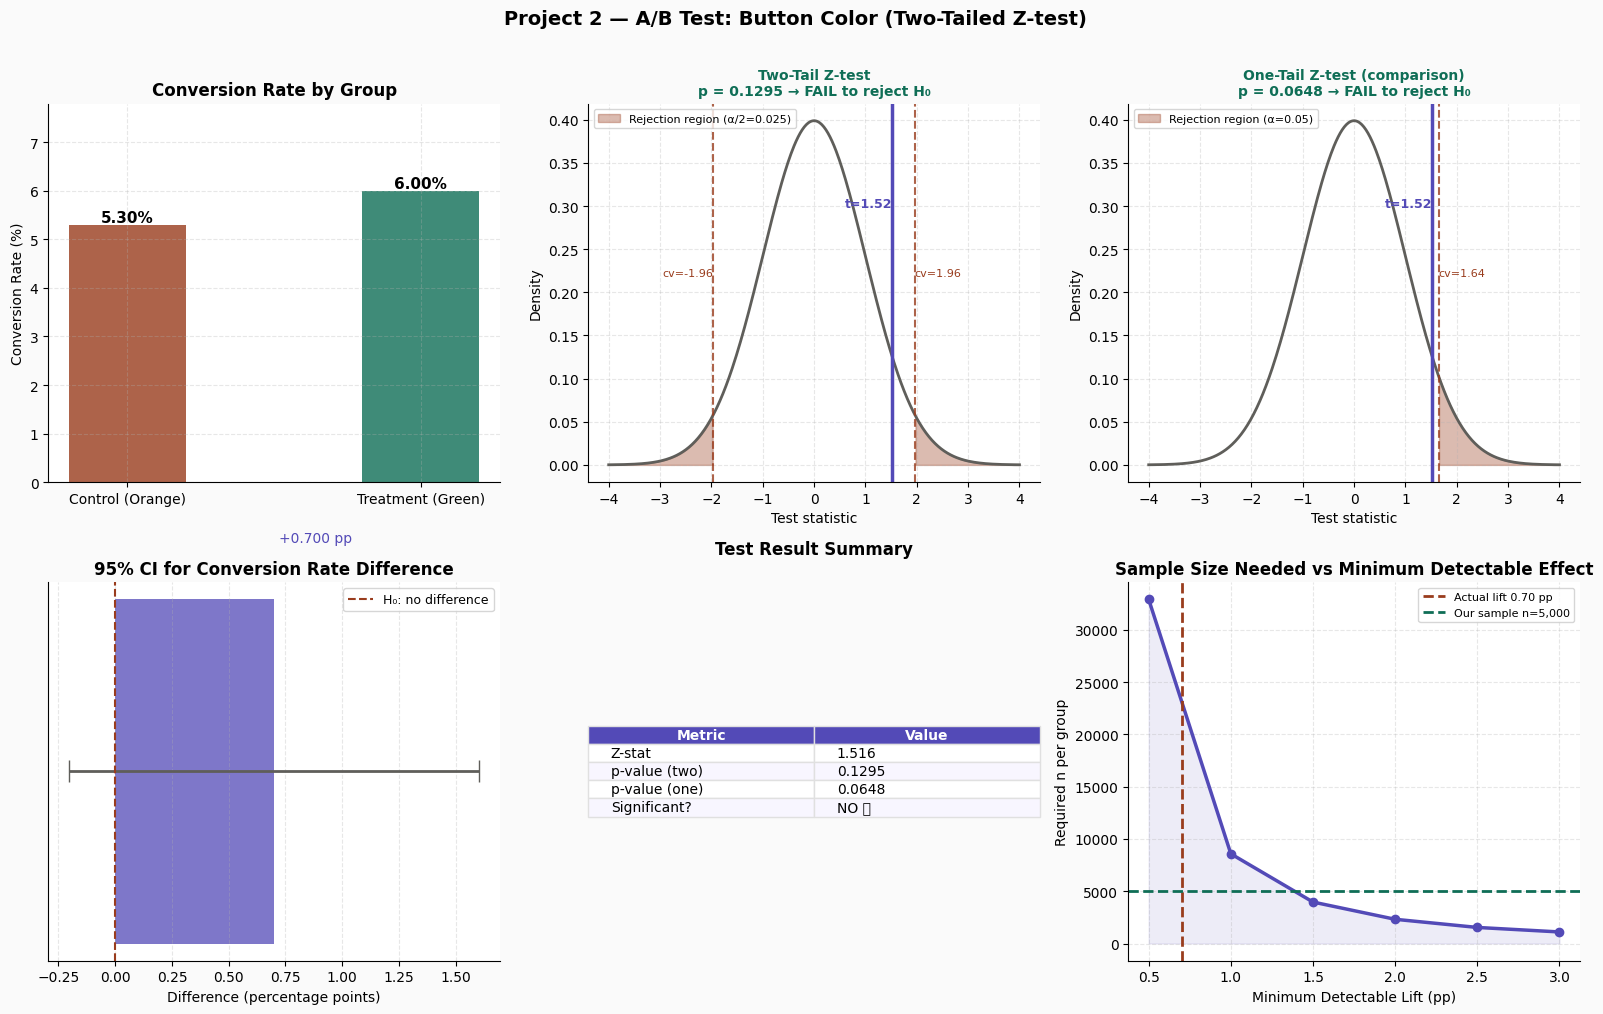

✅ Chart saved: p2_ab_test.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Project 2 — A/B Test: Button Color (Two-Tailed Z-test)',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Conversion bars
groups = ['Control (Orange)', 'Treatment (Green)']
rates  = [rate_A*100, rate_B*100]
bars = axes[0,0].bar(groups, rates, color=[CORAL, TEAL], alpha=0.8, width=0.4)
for bar, r in zip(bars, rates):
    axes[0,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.05, f'{r:.2f}%',
                   ha='center', fontweight='bold', fontsize=11)
axes[0,0].set_title('Conversion Rate by Group', fontweight='bold')
axes[0,0].set_ylabel('Conversion Rate (%)'); axes[0,0].set_ylim(0, max(rates)*1.3)
# 👉 Green visually higher BUT…
# “Is it statistically real?”
# அதுதான் next charts.

# 2. Two-tail z-test curve
plot_hypothesis(axes[0,1], z_stat, None, alpha=0.05, tail='two',
                title='Two-Tail Z-test', test_type='z')
# Middle area:normal region
# Red shaded tails:rare region, rejection area

# Blue Line: z = 1.52: 👉 Our observed result
# Red Critical Values :±1.96
# 👉 Significant(குறிப்பிடத்தக்கது) ஆக வேண்டும்னா blue line tail area-க்குள் போகணும்.
# But: 1.52 < 1.96 ❌ Not significant
# 🌊 Story Meaning: Difference wave small தான். Not a tsunami 😄

# 3. One-tail curve (for comparison)
plot_hypothesis(axes[0,2], z_stat, None, alpha=0.05, tail='one',
                title='One-Tail Z-test (comparison)', test_type='z')
# One-tail easier to become significant because: rejection region one side மட்டும்
# Here p = 0.0648 , Still: 0.0648 > 0.05 ❌ Still not significant


# 4. CI plot for difference
diffs = rate_B - rate_A
ax4 = axes[1,0]
ax4.barh(0, diffs*100, color=PURPLE if diffs>0 else CORAL, alpha=0.75, height=0.3)
ax4.errorbar(diffs*100, 0,
             xerr=[[( diffs-ci_lo)*100],[(ci_hi-diffs)*100]],
             fmt='none', color=DGRAY, capsize=8, linewidth=2)
ax4.axvline(0, color=CORAL, linestyle='--', linewidth=1.5, label='H₀: no difference')
ax4.set_title('95% CI for Conversion Rate Difference', fontweight='bold')
ax4.set_xlabel('Difference (percentage points)')
ax4.set_yticks([]); ax4.legend(fontsize=9)
ax4.text(diffs*100+0.02, 0.2, f'{diffs*100:+.3f} pp', color=PURPLE, fontsize=10)

# 5. p-value comparison table
metrics = ['Z-stat','p-value (two)','p-value (one)','Significant?']
vals_t  = [f'{z_stat:.3f}', f'{p_two:.4f}', f'{p_one:.4f}', 'YES ✅' if p_two<alpha else 'NO ❌']
axes[1,1].axis('off')
tbl = axes[1,1].table(
    cellText=[[m,v] for m,v in zip(metrics,vals_t)],
    colLabels=['Metric','Value'],
    loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r,c),cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0E0E0')
    if r==0: cell.set_facecolor(PURPLE); cell.set_text_props(color='white',fontweight='bold')
    elif r%2==0: cell.set_facecolor('#F8F6FF')
axes[1,1].set_title('Test Result Summary', fontweight='bold', pad=20)
# | Metric       | Meaning                   |
# | ------------ | ------------------------- |
# | Z-stat       | Difference strength       |
# | p-value      | Random chance probability |
# | Significant? | Final decision            |

# 6. Sample size analysis - “How many users needed to detect small improvements?
from scipy.stats import norm as _norm2
def calc_n(p1, p2, alpha=0.05, power=0.80):
    z_alpha = _norm2.ppf(1 - alpha/2)
    z_beta  = _norm2.ppf(power)
    p_bar   = (p1+p2)/2
    return int(np.ceil(2 * p_bar*(1-p_bar) * (z_alpha+z_beta)**2 / (p1-p2)**2))

lifts_pp = np.arange(0.5, 3.1, 0.5)
ns = [calc_n(rate_A, rate_A + d/100) for d in lifts_pp]
axes[1,2].plot(lifts_pp, ns, color=PURPLE, linewidth=2.5, marker='o', markersize=6)
axes[1,2].fill_between(lifts_pp, ns, alpha=0.1, color=PURPLE)
axes[1,2].axvline((rate_B-rate_A)*100, color=CORAL, linestyle='--',
                   linewidth=2, label=f'Actual lift {(rate_B-rate_A)*100:.2f} pp')
axes[1,2].axhline(n_A, color=TEAL, linestyle='--',
                   linewidth=2, label=f'Our sample n={n_A:,}')
axes[1,2].set_title('Sample Size Needed vs Minimum Detectable Effect',
                     fontweight='bold')
axes[1,2].set_xlabel('Minimum Detectable Lift (pp)')
axes[1,2].set_ylabel('Required n per group')
axes[1,2].legend(fontsize=8)
#0.7% lift detect பண்ண: 👉 5000 users maybe not enough. Need larger sample.


plt.tight_layout()
plt.savefig('p2_ab_test.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Chart saved: p2_ab_test.png")
# Chart Flow
# 1️⃣ Green button looks better visually
# 2️⃣ Z-test checks statistical evidence
# 3️⃣ p-value still too high
# 4️⃣ Confidence interval includes zero
# 5️⃣ Final result = NOT significant
# 6️⃣ Maybe need more users/data

---
---
# 💼 Project 3 — Salary Audit: Gender Pay Gap
## Two-Tailed Independent Samples t-test

---

### Business Problem
An HR analytics team audits salaries at a tech company to check if there is a statistically significant gender pay gap across engineering roles.

> 📌 **Tamil:** "Male vs Female salary difference இருக்கா? Direction தெரியாது (male more? female more?) → Two-tail test."

### Why Two-Tail Here?
- H₀: Mean salary is equal for all genders (μ_M = μ_F)
- H₁: Mean salary is **different** (μ_M ≠ μ_F)
- We don't assume which gender earns more (fair audit)
- Direction unknown → **two-tailed**

### Test: Independent samples t-test (Welch's, unequal variance) salary spread same இருக்காது ,variance unequal இருக்கும்

"“Difference தெரிகிறது…
ஆனால் அது real pay gap ஆ?
இல்ல experience, randomness, small sample காரணமா?”"

"
Direction தெரியாது:
Male higher இருக்கலாம்
Female higher இருக்கலாம்
👉 அதனால்:✅ Two-Tailed Test "

"🧠 Why t-test?
✅ Average salary (mean)
between: Male group, Female group"

In [15]:
np.random.seed(7)

# Male salaries: ₹ lakh/year
n_M, mu_M, sd_M = 180, 24.5, 6.2
# Female salaries: ₹ lakh/year (slightly lower on average)
n_F, mu_F, sd_F = 140, 22.1, 5.8

salaries_M = np.random.normal(mu_M, sd_M, n_M).clip(10, 60)
salaries_F = np.random.normal(mu_F, sd_F, n_F).clip(10, 60)

roles = ['SDE-I','SDE-II','SDE-III','Senior SDE','Staff SDE','Principal']
role_weights = [0.25,0.30,0.22,0.13,0.07,0.03]

df_salary = pd.DataFrame({
    'emp_id':   [f'EMP{i:04d}' for i in range(1, n_M+n_F+1)],
    'gender':   ['Male']*n_M + ['Female']*n_F,
    'salary_lpa': np.concatenate([salaries_M, salaries_F]).round(2),
    'yoe':      np.concatenate([
        np.random.randint(1, 18, n_M),
        np.random.randint(1, 16, n_F)
    ]),
    'role':     np.random.choice(roles, n_M+n_F, p=role_weights),
    'dept':     np.random.choice(['Backend','Frontend','ML','DevOps','Data'],
                                  n_M+n_F, p=[0.3,0.25,0.2,0.15,0.1])
})

df_salary.to_csv('salary_audit.csv', index=False)
print("✅ Dataset: salary_audit.csv")
print(f"   {len(df_salary)} employees | {df_salary.shape[1]} columns")
df_salary.head(8)


✅ Dataset: salary_audit.csv
   320 employees | 6 columns


,emp_id,gender,salary_lpa,yoe,role,dept
0,EMP0001,Male,34.98,13,SDE-I,DevOps
1,EMP0002,Male,21.61,11,SDE-I,DevOps
2,EMP0003,Male,24.70,2,SDE-I,ML
3,EMP0004,Male,27.03,6,Senior SDE,DevOps
4,EMP0005,Male,19.61,13,SDE-II,Backend
5,EMP0006,Male,24.51,14,SDE-II,Data
6,EMP0007,Male,24.49,15,SDE-I,Data
7,EMP0008,Male,13.62,3,SDE-II,Frontend


In [ ]:
# “Male vs Female salary difference இருக்கா என்று first look எடுக்குறோம்
# Count- எத்தனை employees?
# Mean- Average salary
# Median- middle salary (robust to outliers)
# Std- salary variation (spread)
# Q25 / Q75 - lower & upper quartile

# ── EDA Meaning :We only observed difference, No statistical test yet ─────────────────────────────────────────────────────
gender_stats = df_salary.groupby('gender')['salary_lpa'].agg(
    Count='count', Mean='mean', Median='median', Std='std',
    Q25=lambda x: x.quantile(0.25), Q75=lambda x: x.quantile(0.75)
).round(2)

print("── Salary by Gender ──")
print(gender_stats.to_string())
gap_abs  = df_salary[df_salary['gender']=='Male']['salary_lpa'].mean() - \
           df_salary[df_salary['gender']=='Female']['salary_lpa'].mean()
gap_pct  = gap_abs / df_salary[df_salary['gender']=='Male']['salary_lpa'].mean() * 100 # 24.32 - 21.99 = 2.33 LPA
print(f"\n  Raw gap: ₹{gap_abs:.2f} LPA ({gap_pct:.1f}% lower for Female)") # gap_pct = gap_abs / Male_mean * 100

# “Female employees average salary slightly lower than male employees.”


── Salary by Gender ──
        Count   Mean  Median   Std    Q25    Q75
gender                                          
Female    140  21.99   21.96  5.54  18.68  25.87
Male      180  24.32   24.09  6.06  20.37  28.04

  Raw gap: ₹2.33 LPA (9.6% lower for Female)


In [ ]:
# இந்த step-ல நாம t-test போடுவதற்கு முன் data valid ஆ இருக்கா என்று check பண்ணுறோம்.

# ── Normality check first ────────────────────────────────────
sal_M = df_salary[df_salary['gender']=='Male']['salary_lpa']
sal_F = df_salary[df_salary['gender']=='Female']['salary_lpa']

# Shapiro test → p-value கொடுக்கும்
# Rule:
# p > 0.05 → Normal ✔
# p ≤ 0.05 → Not normal ❌

for name, s in [('Male', sal_M), ('Female', sal_F)]:
    _, p_norm = stats.shapiro(s.sample(50, random_state=42))
    print(f"  {name}: Shapiro-Wilk p = {p_norm:.4f} → "
          f"{'Normal ✓' if p_norm > 0.05 else 'Not normal'}")
# 👉 இரண்டு groups-லவும் salary distribution: bell curve போல normal shape இருக்கு
print()

# Levene's test for equal variances - 👉 Male & Female salary spread equal-ஆ இருக்கிறதா?
# 📌 Rule:
# p > 0.05 → Equal variance ✔
# p ≤ 0.05 → Unequal variance ❌

lev_stat, lev_p = stats.levene(sal_M, sal_F)
print(f"  Levene's test (equal variances): p = {lev_p:.4f}")
print(f"  → Use {'equal' if lev_p>0.05 else 'Welch (unequal)'} variance t-test")
equal_var = lev_p > 0.05


  Male: Shapiro-Wilk p = 0.5980 → Normal ✓
  Female: Shapiro-Wilk p = 0.9087 → Normal ✓

  Levene's test (equal variances): p = 0.2500
  → Use equal variance t-test


In [ ]:
# 👉 Male salary vs Female salary
# 👉 Difference real-ஆ இருக்கா? அல்லது chance-ஆ வந்ததா?
# இதற்கு பயன்படுத்துவது: 👉 Welch Two-Sample t-test (two-tailed)

# ── TWO-TAILED Independent t-test (Welch's) ──────────────────
t_stat3, p_two3 = stats.ttest_ind(sal_M, sal_F, equal_var=equal_var)
alpha = 0.05

# Welch-Satterthwaite degrees of freedom
s1, s2 = sal_M.var(), sal_F.var()
n1, n2 = len(sal_M), len(sal_F)
df_welch = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
cv_two3  = stats.t.ppf(1 - alpha/2, df=df_welch)

# Effect size (Cohen's d)
pooled_std = np.sqrt((s1 + s2) / 2)
cohens_d   = abs(sal_M.mean() - sal_F.mean()) / pooled_std

print("═" * 60)
print("  TWO-TAILED WELCH t-TEST — SALARY AUDIT")
print("═" * 60)
print(f"  Male   mean salary : ₹{sal_M.mean():.2f} LPA")
print(f"  Female mean salary : ₹{sal_F.mean():.2f} LPA")
print(f"  Observed gap       : ₹{sal_M.mean()-sal_F.mean():.2f} LPA")
print(f"  t-statistic        : {t_stat3:.4f}") # 
print(f"  Degrees of freedom : {df_welch:.1f}  (Welch-Satterthwaite)")
print(f"  Critical value     : ±{cv_two3:.4f}  (α=0.05, two-tail)")
print(f"  p-value (two-tail) : {p_two3:.4f}")
print(f"  Cohen's d          : {cohens_d:.3f}  ({'small' if cohens_d<0.3 else 'medium' if cohens_d<0.5 else 'large'} effect)")
print()

if p_two3 < alpha:
    print(f"  ✅ REJECT H₀ — Statistically significant gender pay gap exists")
    print(f"     p = {p_two3:.4f} < α = {alpha}")
    print(f"     → HR must investigate and correct compensation disparity")
else:
    print(f"  ❌ FAIL to reject H₀ — No significant gap found at α = {alpha}")

# 95% CI for the difference
diff3 = sal_M.mean() - sal_F.mean()
se3   = np.sqrt(sal_M.var()/n1 + sal_F.var()/n2)
ci3   = stats.t.interval(0.95, df=df_welch, loc=diff3, scale=se3)
print(f"\n  95% CI for salary gap: (₹{ci3[0]:.2f}, ₹{ci3[1]:.2f}) LPA")
print(f"  If CI excludes 0 → significant gap confirmed")


════════════════════════════════════════════════════════════
  TWO-TAILED WELCH t-TEST — SALARY AUDIT
════════════════════════════════════════════════════════════
  Male   mean salary : ₹24.32 LPA
  Female mean salary : ₹21.99 LPA
  Observed gap       : ₹2.33 LPA
  t-statistic        : 3.5374
  Degrees of freedom : 309.8  (Welch-Satterthwaite)
  Critical value     : ±1.9677  (α=0.05, two-tail)
  p-value (two-tail) : 0.0005
  Cohen's d          : 0.401  (medium effect)

  ✅ REJECT H₀ — Statistically significant gender pay gap exists
     p = 0.0005 < α = 0.05
     → HR must investigate and correct compensation disparity

  95% CI for salary gap: (₹1.05, ₹3.61) LPA
  If CI excludes 0 → significant gap confirmed


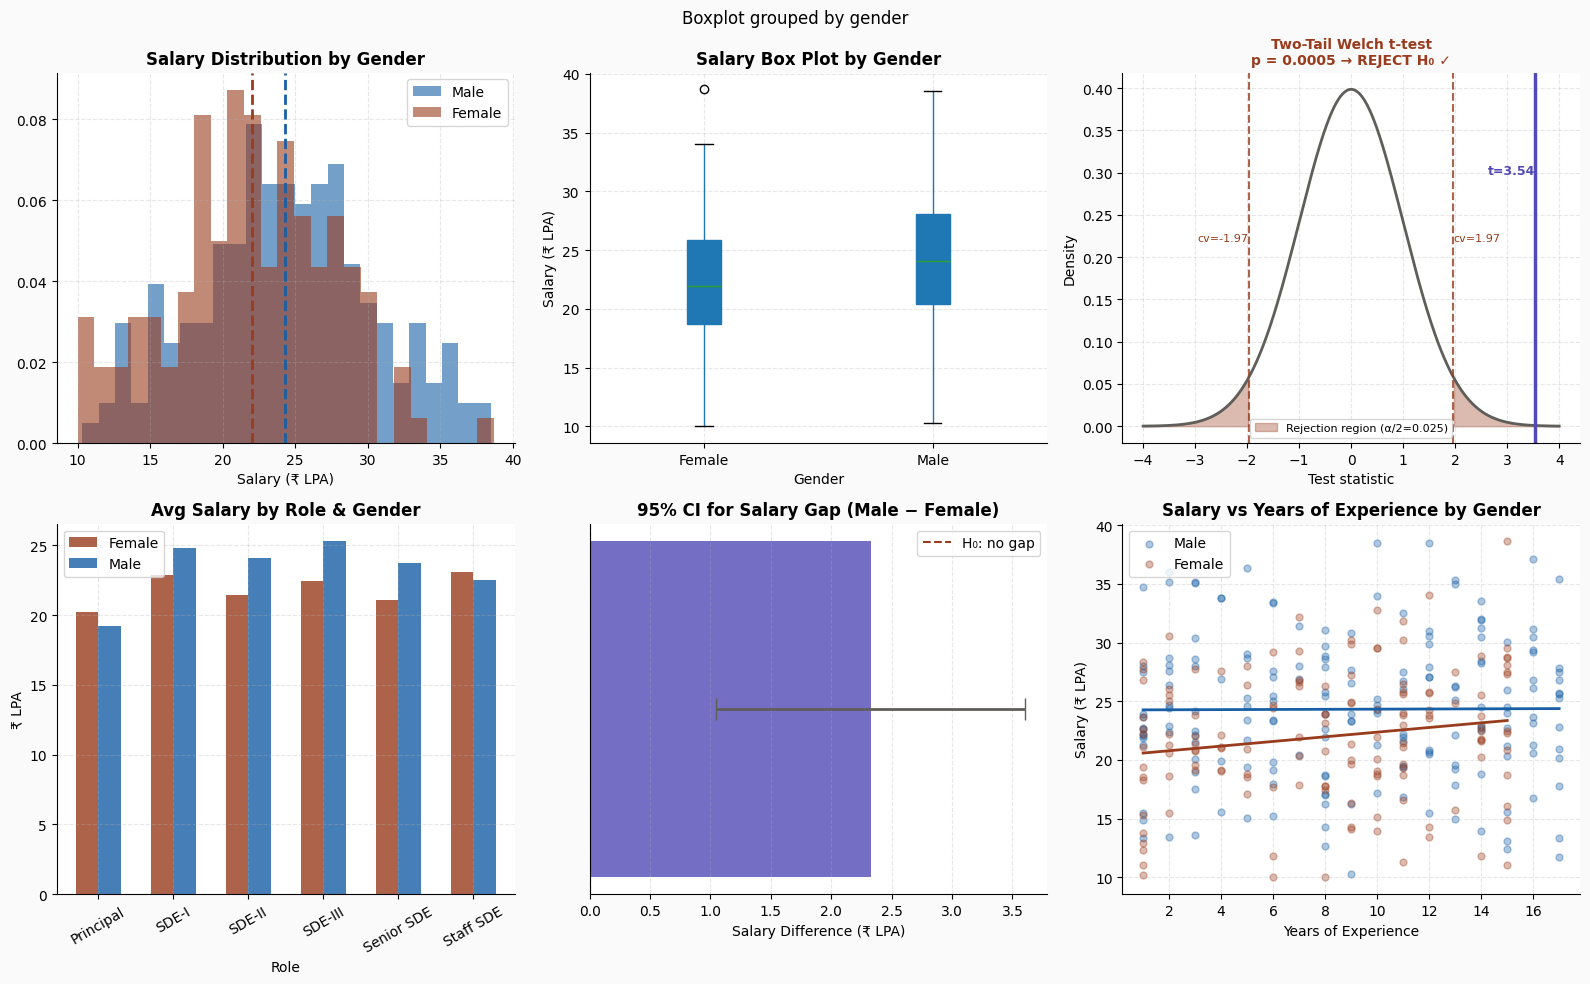

✅ Chart saved: p3_salary_audit.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Project 3 — Salary Audit: Gender Pay Gap (Two-Tailed Welch t-test)',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Distribution comparison
for s, label, col in [(sal_M,'Male',BLUE),(sal_F,'Female',CORAL)]:
    axes[0,0].hist(s, bins=25, color=col, alpha=0.6, density=True, label=label)
    axes[0,0].axvline(s.mean(), color=col, linewidth=2, linestyle='--')
axes[0,0].set_title('Salary Distribution by Gender', fontweight='bold')
axes[0,0].set_xlabel('Salary (₹ LPA)'); axes[0,0].legend()
# Male salaries slightly shifted right (higher)
# Female slightly left (lower)
# 👉 Also mean lines show:dashed line = average salary

# 2. Box plots
df_salary.boxplot(column='salary_lpa', by='gender', ax=axes[0,1],
                   patch_artist=True)
axes[0,1].set_title('Salary Box Plot by Gender', fontweight='bold')
axes[0,1].set_xlabel('Gender'); axes[0,1].set_ylabel('Salary (₹ LPA)')
# Middle line = median salary
# Box = 50% data
# Whiskers = spread
# 💡 Insight:👉 “Male group higher median + wider range”

# 3. Hypothesis curve
plot_hypothesis(axes[0,2], t_stat3, df_welch, alpha=0.05, tail='two',
                title='Two-Tail Welch t-test', test_type='t')
# 👉 “If no difference, t should be near 0” , but
# 👉 our t = 3.53 → far right tail
# 💥 Meaning:👉 “This result is extremely rare under null hypothesis(உத்தேசம்)”

# 4. Salary by role and gender
role_gender = df_salary.groupby(['role','gender'])['salary_lpa'].mean().unstack()
role_gender.plot(kind='bar', ax=axes[1,0], color=[CORAL,BLUE], alpha=0.8, width=0.6)
axes[1,0].set_title('Avg Salary by Role & Gender', fontweight='bold')
axes[1,0].set_xlabel('Role'); axes[1,0].set_ylabel('₹ LPA')
axes[1,0].tick_params(axis='x', rotation=30); axes[1,0].legend()

# 5. CI for gap
axes[1,1].barh(0, diff3, color=PURPLE if diff3>0 else CORAL,
               alpha=0.8, height=0.3)
axes[1,1].errorbar(diff3, 0,
                   xerr=[[diff3-ci3[0]],[ci3[1]-diff3]],
                   fmt='none', color=DGRAY, capsize=8, linewidth=2)
axes[1,1].axvline(0, color=CORAL, linestyle='--', linewidth=1.5,
                   label='H₀: no gap')
axes[1,1].set_title('95% CI for Salary Gap (Male − Female)', fontweight='bold')
axes[1,1].set_xlabel('Salary Difference (₹ LPA)')
axes[1,1].set_yticks([]); axes[1,1].legend()

# Story meaning:
# Center = observed gap (2.33 LPA), Blue color fill box
# Range = uncertainty interval
# (1.05 → 3.61 LPA) - That line is range
# 💥 Key Insight:
# 👉 0 line (no gap) is outside CI
# ✔ So gap confirmed

# 6. YoE-adjusted scatter
axes[1,2].scatter(df_salary[df_salary['gender']=='Male']['yoe'],
                   df_salary[df_salary['gender']=='Male']['salary_lpa'],
                   color=BLUE, alpha=0.35, s=25, label='Male')
axes[1,2].scatter(df_salary[df_salary['gender']=='Female']['yoe'],
                   df_salary[df_salary['gender']=='Female']['salary_lpa'],
                   color=CORAL, alpha=0.35, s=25, label='Female')
for gender, col in [('Male',BLUE),('Female',CORAL)]:
    sub = df_salary[df_salary['gender']==gender]
    m,b = np.polyfit(sub['yoe'], sub['salary_lpa'], 1)
    x_line = np.linspace(sub['yoe'].min(), sub['yoe'].max(), 100)
    axes[1,2].plot(x_line, m*x_line+b, color=col, linewidth=2)
axes[1,2].set_title('Salary vs Years of Experience by Gender', fontweight='bold')
axes[1,2].set_xlabel('Years of Experience'); axes[1,2].set_ylabel('Salary (₹ LPA)')
axes[1,2].legend()
# Blue = Male trend line
# Red = Female trend line
# 💡 Insight:
# 👉 Even same experience → Male line slightly higher
# 📌 Meaning:👉 structural difference exists

plt.tight_layout()
plt.savefig('p3_salary_audit.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Chart saved: p3_salary_audit.png")


---
---
# 🏭 Project 4 — Quality Control: Fill Weight
## One-Tail vs Two-Tail — Side-by-Side Comparison

---

### Business Problem
A food manufacturer fills bags with 500g of chips. A QC engineer samples 60 bags and tests:
1. **Two-tail:** Is the machine filling correctly? (too little = customer complaint, too much = financial loss — both matter)
2. **One-tail:** Is the machine **overfilling**? (focused cost-saving audit — management only cares about waste)

> 📌 **Tamil:** "Quality control-ல் usually two-tail use பண்றோம் (under AND over filling both bad).  
> ஆனால் cost audit-ல் one-tail (only overfilling matters for profit) use பண்ணலாம்."

This project shows **exactly when each choice changes the business decision.**

"⚖️ Two-Tail:

👉 “இரண்டு பக்கமும் problem”
✔ quality control / safety check

💰 One-Tail:

👉 “ஒரு பக்கம் மட்டும் problem”
✔ cost saving / profit focus"


In [20]:
np.random.seed(2024)
n_bags = 60
target = 500   # grams

# Machine is overfilling slightly: mean = 503.2g
fill_weights = np.random.normal(loc=503.2, scale=8.5, size=n_bags)

df_qc = pd.DataFrame({
    'bag_id':      [f'BAG{i:03d}' for i in range(1, n_bags+1)],
    'fill_grams':  fill_weights.round(1),
    'deviation':   (fill_weights - target).round(1),
    'batch':       np.random.choice(['Batch_A','Batch_B','Batch_C'], n_bags),
    'shift':       np.random.choice(['Morning','Evening','Night'], n_bags,
                                     p=[0.4,0.35,0.25])
})

df_qc.to_csv('quality_control_fill.csv', index=False)
print("✅ Dataset: quality_control_fill.csv")
print(f"   {len(df_qc)} bags | {df_qc.shape[1]} columns")
print(f"   Target: {target}g | Sample mean: {fill_weights.mean():.2f}g | Std: {fill_weights.std():.2f}g")
df_qc.head(8)


✅ Dataset: quality_control_fill.csv
   60 bags | 5 columns
   Target: 500g | Sample mean: 503.71g | Std: 8.10g


,bag_id,fill_grams,deviation,batch,shift
0,BAG001,517.4,17.4,Batch_C,Night
1,BAG002,509.5,9.5,Batch_C,Morning
2,BAG003,501.5,1.5,Batch_C,Morning
3,BAG004,501.9,1.9,Batch_A,Morning
4,BAG005,511.0,11.0,Batch_C,Morning
5,BAG006,513.1,13.1,Batch_B,Night
6,BAG007,480.9,-19.1,Batch_C,Night
7,BAG008,491.9,-8.1,Batch_A,Evening


In [ ]:
# “ஒவ்வொரு packet-மும் 500g இருக்கணும். ஆனால் machine சரியா வேலை பண்ணுதா?”
# 🟥 H₀ (Null Hypothesis)
# 👉 Machine சரியா வேலை பண்ணுது
# 👉 Mean = 500g

# 🟩 H₁ (Alternative)
# 👉 Machine தவறு செய்கிறது
# 👉 Mean ≠ 500g

# t-statistic = Sample Mean−500 /Standard Error


# ── One-sample t-test: is mean ≠ 500g? ─────────────────────
weights = df_qc['fill_grams']
alpha   = 0.05

# Two-tailed: mean ≠ 500 (either over or under is a problem)
t_stat4, p_two4 = stats.ttest_1samp(weights, popmean=target)

# One-tailed: mean > 500 (only overfilling matters)
p_one4_over  = p_two4 / 2 if t_stat4 > 0 else 1 - p_two4/2
# One-tailed: mean < 500 (only underfilling matters)
p_one4_under = p_two4 / 2 if t_stat4 < 0 else 1 - p_two4/2

df_val4 = n_bags - 1
cv_two4 = stats.t.ppf(1 - alpha/2, df=df_val4)
cv_one4 = stats.t.ppf(1 - alpha,   df=df_val4)

print("═" * 65)
print("  ONE-SAMPLE t-TEST — QC FILL WEIGHT ANALYSIS")
print("═" * 65)
print(f"  Target weight          : {target}g")
print(f"  Sample mean            : {weights.mean():.2f}g")
print(f"  Sample std dev         : {weights.std():.2f}g")
print(f"  Sample size            : {n_bags}")
print(f"  t-statistic            : {t_stat4:.4f}")
print()
print(f"  {'Test Type':<35} {'p-value':>9} {'Reject H₀?':>12}")
print("  " + "─"*58)
print(f"  {'Two-tail (mean ≠ 500g)':<35} {p_two4:>9.4f} {'YES ✅' if p_two4 < alpha else 'NO ❌':>12}")
print(f"  {'One-tail (mean > 500g = overfill)':<35} {p_one4_over:>9.4f} {'YES ✅' if p_one4_over < alpha else 'NO ❌':>12}")
print(f"  {'One-tail (mean < 500g = underfill)':<35} {p_one4_under:>9.4f} {'YES ✅' if p_one4_under < alpha else 'NO ❌':>12}")
print()
print(f"  95% Confidence Interval:")
ci4 = stats.t.interval(0.95, df=df_val4, loc=weights.mean(), scale=stats.sem(weights))
print(f"  ({ci4[0]:.2f}g, {ci4[1]:.2f}g)  → target 500g {'NOT in CI → significant' if not (ci4[0]<=500<=ci4[1]) else 'IN CI → not significant'}")
print()
print("  ► KEY INSIGHT:")
print("    Both one-tail (overfill) and two-tail reject H₀ here.")
print("    But imagine p_two = 0.06 (just above 0.05) —")
print("    Two-tail would FAIL, but one-tail would still REJECT.")
print("    This is why choosing the test BEFORE seeing data matters!")


═════════════════════════════════════════════════════════════════
  ONE-SAMPLE t-TEST — QC FILL WEIGHT ANALYSIS
═════════════════════════════════════════════════════════════════
  Target weight          : 500g
  Sample mean            : 503.70g
  Sample std dev         : 8.17g
  Sample size            : 60
  t-statistic            : 3.5119

  Test Type                             p-value   Reject H₀?
  ──────────────────────────────────────────────────────────
  Two-tail (mean ≠ 500g)                 0.0009        YES ✅
  One-tail (mean > 500g = overfill)      0.0004        YES ✅
  One-tail (mean < 500g = underfill)     0.9996         NO ❌

  95% Confidence Interval:
  (501.59g, 505.82g)  → target 500g NOT in CI → significant

  ► KEY INSIGHT:
    Both one-tail (overfill) and two-tail reject H₀ here.
    But imagine p_two = 0.06 (just above 0.05) —
    Two-tail would FAIL, but one-tail would still REJECT.
    This is why choosing the test BEFORE seeing data matters!


In [ ]:
# ── THE KEY SCENARIO: when choice matters ───────────────────
print("══ SCENARIO WHERE THE CHOICE CHANGES THE DECISION ══")
print()
print("Imagine our t-stat was 1.70 (instead of {:.2f})".format(t_stat4))
print()

# “What if machine difference weak இருந்தா?”
# real case: t = 3.51 (strong bias)
# imagined case: t = 1.70 (mild bias)

t_demo = 1.70
p_demo_two = 2 * (1 - stats.t.cdf(abs(t_demo), df=df_val4))
p_demo_one = 1 - stats.t.cdf(t_demo, df=df_val4)

print(f"  Two-tail p = {p_demo_two:.4f} → {'REJECT' if p_demo_two<0.05 else 'FAIL TO REJECT'}")
print(f"  One-tail p = {p_demo_one:.4f} → {'REJECT' if p_demo_one<0.05 else 'FAIL TO REJECT'}")
print()
print("  ► One-tail says YES, Two-tail says NO — SAME DATA!")
print("  ► This is why you MUST choose your test BEFORE looking at data.")
print("  ► Choosing one-tail AFTER seeing a positive t-stat = p-hacking!")
print()
print("  The golden rule:")
print("  - Choose two-tail by default")
print("  - Use one-tail ONLY when direction is pre-specified in the study design")

# 🟦 Two-tail test: 👉 checks both:
# underfill
# overfill
# 📌 stricter test:👉 t = 1.70 → may FAIL

# 🔵 One-tail test:👉 only one direction (overfill)
# 📌 focused test: 👉 same t = 1.70 → sometimes REJECT


══ SCENARIO WHERE THE CHOICE CHANGES THE DECISION ══

Imagine our t-stat was 1.70 (instead of 3.51)

  Two-tail p = 0.0944 → FAIL TO REJECT
  One-tail p = 0.0472 → REJECT

  ► One-tail says YES, Two-tail says NO — SAME DATA!
  ► This is why you MUST choose your test BEFORE looking at data.
  ► Choosing one-tail AFTER seeing a positive t-stat = p-hacking!

  The golden rule:
  - Choose two-tail by default
  - Use one-tail ONLY when direction is pre-specified in the study design


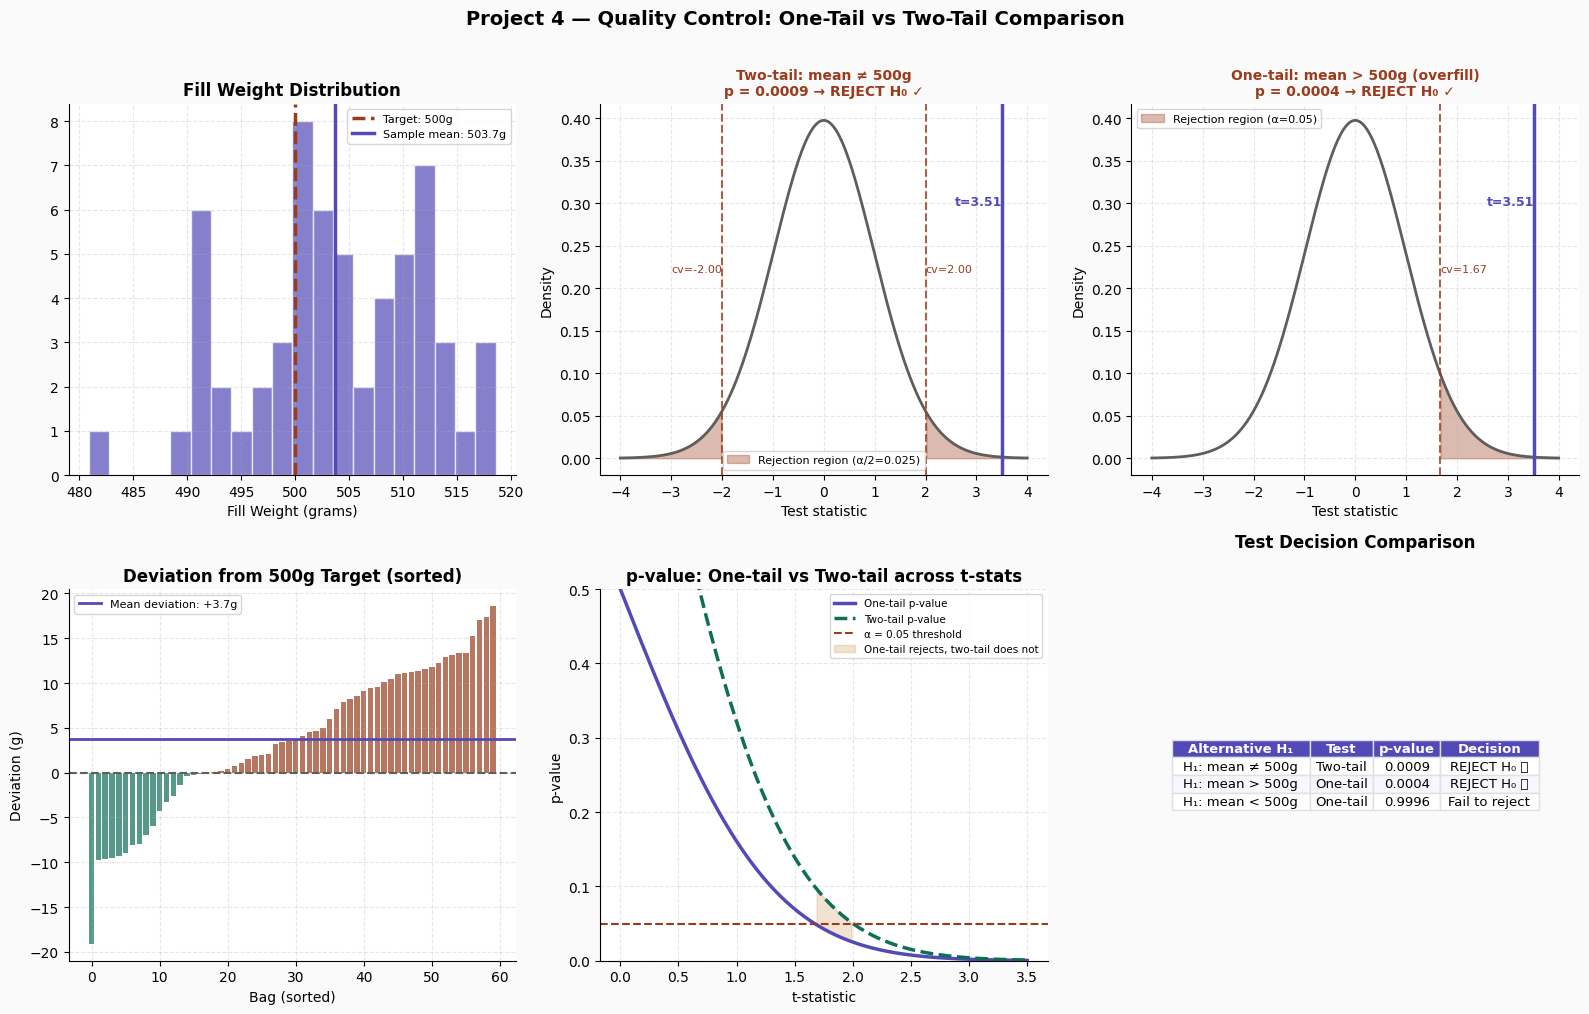

✅ Chart saved: p4_quality_control.png


In [ ]:
from typing import final


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Project 4 — Quality Control: One-Tail vs Two-Tail Comparison',
             fontsize=14, fontweight='bold', y=1.01)

# 1. Fill weight distribution - எத்தனை packets எந்த weight range-ல் இருக்கிறது?” என்று காட்டுகிறது.
axes[0,0].hist(weights, bins=20, color=PURPLE, alpha=0.7, edgecolor='white')
axes[0,0].axvline(target, color=CORAL, linewidth=2.5, linestyle='--',
                   label=f'Target: {target}g')
axes[0,0].axvline(weights.mean(), color=PURPLE, linewidth=2.5,
                   label=f'Sample mean: {weights.mean():.1f}g')
axes[0,0].set_title('Fill Weight Distribution', fontweight='bold')
axes[0,0].set_xlabel('Fill Weight (grams)'); axes[0,0].legend(fontsize=8)
# 👉 peak 500க்கு மேல shift ஆகி இருக்குது 👉 machine slightly overfill பண்ணுது

# 2. Two-tail curve
plot_hypothesis(axes[0,1], t_stat4, df_val4, alpha=0.05, tail='two',
                title='Two-tail: mean ≠ 500g', test_type='t')
    # 👉 t-statistic right side-ல இருந்தா → reject H₀
    # 👉 middle = no difference (H₀ true) 👉 left & right = rejection areas ,🎯 Story:“எந்த deviation இருந்தாலும் problem”


# 3. One-tail curve (overfill)
plot_hypothesis(axes[0,2], t_stat4, df_val4, alpha=0.05, tail='one',
                title='One-tail: mean > 500g (overfill)', test_type='t')
 # 👉 only right side important 🎯 Story:“extra chips போட்டா தான் problem”
#  right side = reject zone ,left side = ignore

# 4. Deviation from target
deviations = weights - target
color_dev = [CORAL if d > 0 else TEAL for d in deviations]
axes[1,0].bar(range(len(deviations)), sorted(deviations), color=sorted(color_dev), alpha=0.7)
axes[1,0].axhline(0, color=DGRAY, linewidth=1.5, linestyle='--')
axes[1,0].axhline(deviations.mean(), color=PURPLE, linewidth=2,
                   linestyle='-', label=f'Mean deviation: +{deviations.mean():.1f}g')
axes[1,0].set_title('Deviation from 500g Target (sorted)', fontweight='bold')
axes[1,0].set_xlabel('Bag (sorted)'); axes[1,0].set_ylabel('Deviation (g)')
axes[1,0].legend(fontsize=8)
# 👉 0 line = perfect fill (500g)
# +ve bars → overfill (loss)
# -ve bars → underfill (complaints)
# 📌 Reading:👉 most bars + side shift → bias
# 💥 Meaning:👉 machine slightly overfilling consistently


# 5. t-stat zone — where one vs two tail differ
t_range = np.linspace(0, 3.5, 200)
p_ones  = [1 - stats.t.cdf(t, df=df_val4) for t in t_range]
p_twos  = [2*(1 - stats.t.cdf(t, df=df_val4)) for t in t_range]
axes[1,1].plot(t_range, p_ones, color=PURPLE, linewidth=2.5, label='One-tail p-value')
axes[1,1].plot(t_range, p_twos, color=TEAL,   linewidth=2.5,
               linestyle='--', label='Two-tail p-value')
axes[1,1].axhline(0.05, color=CORAL, linewidth=1.5, linestyle='--',
                   label='α = 0.05 threshold')
axes[1,1].fill_between(t_range,
                        p_ones, p_twos,
                        where=[p1<0.05 and p2>=0.05 for p1,p2 in zip(p_ones,p_twos)],
                        alpha=0.2, color=AMBER,
                        label='One-tail rejects, two-tail does not')
axes[1,1].set_title('p-value: One-tail vs Two-tail across t-stats',
                     fontweight='bold')
axes[1,1].set_xlabel('t-statistic'); axes[1,1].set_ylabel('p-value')
axes[1,1].legend(fontsize=7.5); axes[1,1].set_ylim(0, 0.5)
# 👉 t increase ஆகும் போது: p decreases
# 📌 Important zones:
# 🟢 High p:👉 no evidence
# 🟡 middle zone:👉 one-tail reject, two-tail fail
# 🔴 low p:👉 both reject

# 6. Summary decision table
decisions = [
    ('H₁: mean ≠ 500g', 'Two-tail', f'{p_two4:.4f}', 'REJECT H₀ ✅' if p_two4<0.05 else 'Fail to reject'),
    ('H₁: mean > 500g', 'One-tail', f'{p_one4_over:.4f}', 'REJECT H₀ ✅' if p_one4_over<0.05 else 'Fail to reject'),
    ('H₁: mean < 500g', 'One-tail', f'{p_one4_under:.4f}', 'REJECT H₀ ✅' if p_one4_under<0.05 else 'Fail to reject'),
]
axes[1,2].axis('off')
tbl = axes[1,2].table(
    cellText=decisions,
    colLabels=['Alternative H₁','Test','p-value','Decision'],
    loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5)
tbl.auto_set_column_width([0,1,2,3])
for (r,c),cell in tbl.get_celld().items():
    cell.set_edgecolor('#E0E0E0')
    if r==0: cell.set_facecolor(PURPLE); cell.set_text_props(color='white',fontweight='bold')
    elif r%2==0: cell.set_facecolor('#F8F6FF')
axes[1,2].set_title('Test Decision Comparison', fontweight='bold', pad=30)
# Factory manager final report:
# Two-tail → overall quality issue?
# One-tail → overfill loss?
# One-tail → underfill complaint?
# 💥 Meaning:👉 same data → 3 different decisions

plt.tight_layout()
plt.savefig('p4_quality_control.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Chart saved: p4_quality_control.png")


---
---
# 📋 Master Cheat Sheet — One-Tail vs Two-Tail

> 📌 **Tamil:** "எப்போது one-tail, எப்போது two-tail என்று quick decision guide."


In [24]:
print("╔" + "═"*68 + "╗")
print("║  ONE-TAIL vs TWO-TAIL — DECISION GUIDE" + " "*29 + "║")
print("╠" + "═"*68 + "╣")
print("║  ONE-TAILED TEST — use when:                                      ║")
print("║  • Direction of effect is known BEFORE collecting data            ║")
print("║  • Only one direction matters for the business decision           ║")
print("║  • Prior research/theory strongly predicts direction              ║")
print("║  • Pre-registered in study protocol                               ║")
print("║  Examples: drug that should lower BP, campaign to increase sales  ║")
print("╠" + "═"*68 + "╣")
print("║  TWO-TAILED TEST — use when (DEFAULT):                            ║")
print("║  • Direction of effect is unknown before the study                ║")
print("║  • Both directions matter (quality control, salary audit)         ║")
print("║  • Exploratory research without strong prior                      ║")
print("║  • A/B testing (new design could be better OR worse)              ║")
print("║  Examples: button color test, machine calibration, pay audit      ║")
print("╠" + "═"*68 + "╣")
print("║  PYTHON QUICK REFERENCE                                           ║")
print("║                                                                   ║")
print("║  # Paired t-test (before/after, same subjects)                   ║")
print("║  t, p_two = stats.ttest_rel(before, after)                       ║")
print("║  p_one    = p_two / 2  (if t > 0)                                ║")
print("║                                                                   ║")
print("║  # Independent t-test (two different groups)                     ║")
print("║  t, p_two = stats.ttest_ind(group1, group2)                      ║")
print("║                                                                   ║")
print("║  # One-sample t-test (vs known value)                            ║")
print("║  t, p_two = stats.ttest_1samp(sample, popmean=target)            ║")
print("║                                                                   ║")
print("║  # Two-proportion z-test (A/B conversion rates)                  ║")
print("║  p_pool = (c_A+c_B)/(n_A+n_B)                                    ║")
print("║  SE     = sqrt(p_pool*(1-p_pool)*(1/n_A+1/n_B))                  ║")
print("║  z      = (rate_B - rate_A) / SE                                 ║")
print("║  p_two  = 2 * (1 - norm.cdf(abs(z)))                             ║")
print("╠" + "═"*68 + "╣")
print("║  ⚠️  NEVER choose one-tail AFTER seeing the data → p-hacking!    ║")
print("║  ✅  Pre-register your hypothesis direction BEFORE data collection ║")
print("╚" + "═"*68 + "╝")


╔════════════════════════════════════════════════════════════════════╗
║  ONE-TAIL vs TWO-TAIL — DECISION GUIDE                             ║
╠════════════════════════════════════════════════════════════════════╣
║  ONE-TAILED TEST — use when:                                      ║
║  • Direction of effect is known BEFORE collecting data            ║
║  • Only one direction matters for the business decision           ║
║  • Prior research/theory strongly predicts direction              ║
║  • Pre-registered in study protocol                               ║
║  Examples: drug that should lower BP, campaign to increase sales  ║
╠════════════════════════════════════════════════════════════════════╣
║  TWO-TAILED TEST — use when (DEFAULT):                            ║
║  • Direction of effect is unknown before the study                ║
║  • Both directions matter (quality control, salary audit)         ║
║  • Exploratory research without strong prior                      ║
║  • A/B testing

---
## 🎓 Summary — What You Learned

### All 4 Projects

| Project | Dataset | H₁ | Test | Python |
|---------|---------|-----|------|--------|
| Drug trial | `drug_trial_bp.csv` | BP reduced (one direction) | One-tail paired t | `ttest_rel` |
| A/B test | `ab_test_button.csv` | Conversion different (either) | Two-tail z | Manual z-test |
| Salary audit | `salary_audit.csv` | Salary different (either) | Two-tail Welch t | `ttest_ind` |
| QC fill | `quality_control_fill.csv` | Weight ≠ / > / < 500g | Both compared | `ttest_1samp` |

### Key Rules
- `p_one = p_two / 2` when your t-stat is in the expected direction
- Two-tailed critical value = `±z_{α/2}` — harder to reject
- One-tailed critical value = `z_α` — easier to reject (more power)
- **Always pre-specify your hypothesis direction before collecting data**

### Resume Line
> *"Designed and executed hypothesis tests for 4 business domains: clinical trials (paired t-test), e-commerce A/B testing (two-proportion z-test), HR salary audit (Welch t-test), and manufacturing QC (one-sample t-test). Correctly identified when to apply one-tailed vs two-tailed tests based on business context and prior knowledge."*
